In [3]:
import sys
print(sys.executable)


/home/tclark/anaconda3/bin/python


In [4]:
import os
import pandas as pd
from supabase import create_client
from dotenv import load_dotenv

# --- Load environment ---
load_dotenv()
SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_KEY")

# --- Initialize Supabase client ---
supabase = create_client(SUPABASE_URL, SUPABASE_KEY)

# --- Pull data from Supabase ---
response = supabase.table("press_releases_clean").select("*").execute()

# --- Convert to DataFrame ---
articles_df = pd.DataFrame(response.data)

# --- Display preview ---
articles_df.head()


,id,title,url,date,scraped_at,content,author,status,updated_at,embedding
0,4a4521db-3af0-4876-a355-f8c2a1844818,Federal Reserve Board publishes Community Rein...,https://www.federalreserve.gov/newsevents/pres...,2020-03-06,2025-10-23T03:47:51.094731+00:00,The Federal Reserve Board on Friday released a...,None,complete,2025-10-23T04:15:37.376961+00:00,"[0.0020967724,-0.05268078,-0.039224133,-0.0346..."
1,4a588106-a557-4845-a456-88ca43e3f636,Agencies release fact sheet to clarify Bank Se...,https://www.federalreserve.gov/newsevents/pres...,2020-11-19,2025-10-23T03:47:51.094042+00:00,Federal financial institution regulatory agenc...,None,complete,2025-10-23T04:07:20.115934+00:00,"[0.04500519,-0.049324825,-0.020882733,0.019640..."
2,4a6eb907-2547-4439-889b-ea242eb543b4,Federal Reserve Board announces the results fr...,https://www.federalreserve.gov/newsevents/pres...,2023-04-28,2025-10-23T03:47:55.069432+00:00,The Federal Reserve Board on Friday announced ...,None,complete,2025-10-23T04:23:58.342435+00:00,"[-0.006883422,-0.027332025,-0.043720484,-0.004..."
3,4a9f3805-997c-4f29-93f9-6c9f45a5a655,Federal Reserve Board issues enforcement actio...,https://www.federalreserve.gov/newsevents/pres...,2017-01-27,2025-10-23T03:47:47.118904+00:00,The Federal Reserve Board on Friday announced ...,None,complete,2025-10-23T03:57:13.617122+00:00,"[-0.030697979,-0.00026343472,-0.0014297758,-0...."
4,4aa45157-fc86-4646-9a02-028ec0ad665f,Philip N. Jefferson sworn in as Vice Chair of ...,https://www.federalreserve.gov/newsevents/pres...,2023-09-13,2025-10-23T03:47:55.069155+00:00,Chair Jerome H. Powell swears in Philip N. Jef...,None,complete,2025-10-23T04:22:54.216047+00:00,"[-0.06714406,0.004745175,0.039318115,-0.024394..."


In [5]:
articles_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          1000 non-null   object
 1   title       1000 non-null   object
 2   url         1000 non-null   object
 3   date        1000 non-null   object
 4   scraped_at  1000 non-null   object
 5   content     1000 non-null   object
 6   author      4 non-null      object
 7   status      1000 non-null   object
 8   updated_at  1000 non-null   object
 9   embedding   1000 non-null   object
dtypes: object(10)
memory usage: 78.3+ KB


In [6]:
# Drop unused columns
articles_df = articles_df.drop(columns=["id", "author"], errors="ignore")

# Confirm structure
articles_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   title       1000 non-null   object
 1   url         1000 non-null   object
 2   date        1000 non-null   object
 3   scraped_at  1000 non-null   object
 4   content     1000 non-null   object
 5   status      1000 non-null   object
 6   updated_at  1000 non-null   object
 7   embedding   1000 non-null   object
dtypes: object(8)
memory usage: 62.6+ KB


In [7]:
articles_df["word_count"] = articles_df["content"].apply(lambda x: len(str(x).split()))
articles_df[["title", "date", "word_count"]].head(5)


,title,date,word_count
0,Federal Reserve Board publishes Community Rein...,2020-03-06,84
1,Agencies release fact sheet to clarify Bank Se...,2020-11-19,212
2,Federal Reserve Board announces the results fr...,2023-04-28,291
3,Federal Reserve Board issues enforcement actio...,2017-01-27,36
4,Philip N. Jefferson sworn in as Vice Chair of ...,2023-09-13,142


In [8]:
# Ensure 'date' is a real datetime column
articles_df["date"] = pd.to_datetime(articles_df["date"], errors="coerce")

# Drop any rows where date could not be parsed
articles_df = articles_df[articles_df["date"].notnull()]

# Now safely extract year
articles_df["year"] = articles_df["date"].dt.year


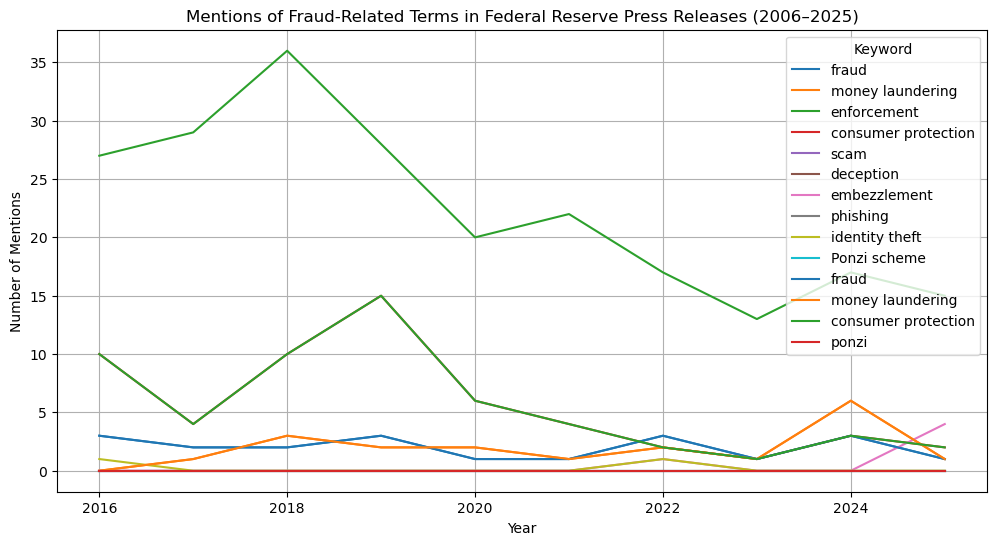

In [9]:
import matplotlib.pyplot as plt

# Make sure dates are datetime and year exists
articles_df["date"] = pd.to_datetime(articles_df["date"], errors="coerce")
articles_df["year"] = articles_df["date"].dt.year

# Combine all text into lowercase for keyword matching
articles_df["content_lower"] = articles_df["content"].fillna("").str.lower()

# Keywords to track
keywords = ["fraud", "money laundering", "enforcement", "consumer protection", "scam", "deception",
            "embezzlement", "phishing", "identity theft", "Ponzi scheme", "fraud", "money laundering",
            "consumer protection", "ponzi"] 

# Count keyword hits per article
for kw in keywords:
    articles_df[kw] = articles_df["content_lower"].str.contains(kw, case=False, na=False)

# Aggregate counts by year
keyword_trends = (
    articles_df.groupby("year")[keywords]
    .sum()
    .reset_index()
)

# Plot the trends
keyword_trends.plot(x="year", figsize=(12,6))
plt.title("Mentions of Fraud-Related Terms in Federal Reserve Press Releases (2006–2025)")
plt.ylabel("Number of Mentions")
plt.xlabel("Year")
plt.legend(title="Keyword")
plt.grid(True)
plt.show()
